# Tutorial 4: DOE Planning (`grid` vs `sobol`)

Estimated time: 20-35 minutes

## Prerequisites
No optional dependencies required.

## Learning aims
- Primary package aim: compare DOE strategies and understand planning outputs
- Secondary scientific aim: reason about coverage, budget, and bias in simulation campaigns

## Success criteria
- you can justify a DOE strategy for a given model dimensionality and run budget


## Why this tutorial matters

DOE strategy is a **budget question**: given N runs you can afford to execute, where do you place them in input space? Two strategies in this curriculum:

- **`grid`** — Cartesian product of per-input value lists. Predictable, easy to interpret, *wastes runs in dimensions that don't matter much*. Great when you want a clean response surface in 1-3 dimensions.
- **`sobol`** — A deterministic, low-discrepancy *space-filling* sequence. The same N points spread out more uniformly across the input box than a random sample, and far better than a regular grid in 4+ dimensions. Don't be fooled by the visual at 2D — Sobol's payoff is at higher dimensionality.

This tutorial shows the visual difference at 2D so you can extrapolate. By the end you should be able to pick the right strategy for your model's actual dimensionality, not by reflex.


## Step 1: Run both planning commands


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


In [2]:
run_mm_cli('plan', 'tutorials/specs/model.toy.grid.json')
run_mm_cli('plan', 'tutorials/specs/model.toy.sobol.json')


$ bayesmm plan tutorials/specs/model.toy.grid.json
Plan points: 9
Preview:
1: {'a': 0.0, 'b': 0.0}
2: {'a': 0.0, 'b': 1.0}
3: {'a': 0.0, 'b': 2.0}
4: {'a': 1.0, 'b': 0.0}
5: {'a': 1.0, 'b': 1.0}
$ bayesmm plan tutorials/specs/model.toy.sobol.json
Plan points: 9
Preview:
1: {'a': 1.1932564191520214, 'b': 1.3127474077045918}
2: {'a': 0.5671679321676493, 'b': 0.39746201038360596}
3: {'a': 0.06245388649404049, 'b': 1.8685509636998177}
4: {'a': 1.686345100402832, 'b': 0.9200668297708035}
5: {'a': 1.9049059096723795, 'b': 1.6158733870834112}
/Users/barakraveh/Git/metamodeler_codex_scaffold_docs/src/bayesian_metamodeling/designs/planner.py:62: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  unit_samples = engine.random(n=n_points)


0

**`plan` is read-only.** It enumerates the DOE points the spec will produce without executing anything. Use it for budgeting *before* launching a run: a 6-input grid with 4 levels each is `4⁶ = 4096` runs; the same coverage in Sobol is closer to `256`. Catching that asymmetry on `plan` is hours of compute time saved.


## Step 2: Plot DOE points (graphic)


**First, actually run the Sobol spec** so the scatter has Sobol points to plot. The toy program is fast (~9 sub-second runs); the cost is negligible. We previously ran the grid spec in T1, so its sweep is already on disk.


In [3]:
run_mm_cli("run", "tutorials/specs/model.toy.sobol.json")


$ bayesmm run tutorials/specs/model.toy.sobol.json
Running point 1/9: {'a': 1.1932564191520214, 'b': 1.3127474077045918}
Running point 2/9: {'a': 0.5671679321676493, 'b': 0.39746201038360596}
Running point 3/9: {'a': 0.06245388649404049, 'b': 1.8685509636998177}
Running point 4/9: {'a': 1.686345100402832, 'b': 0.9200668297708035}
Running point 5/9: {'a': 1.9049059096723795, 'b': 1.6158733870834112}
Running point 6/9: {'a': 0.28099463507533073, 'b': 0.6581079978495836}
Running point 7/9: {'a': 0.8481799960136414, 'b': 1.077645132318139}
Running point 8/9: {'a': 1.4742885436862707, 'b': 0.14918005280196667}
Running point 9/9: {'a': 1.2711884714663029, 'b': 1.9727632887661457}
Stored sweep run: 74cea6eb7ad04386b52bff76b3ddffe3
Run complete: 9 successful runs


0

**Predict before you run.** Both DOEs use 9 points on the box `a, b ∈ [0, 2]`.

- The grid will be a tidy 3×3 lattice on the integers `{0, 1, 2}`. You know exactly where every point falls.
- Sobol with `n_points=9` will *not* be a lattice. It'll spread 9 points across the box to fill it as uniformly as possible, with no two points in the same row or column at the same fractional position.

Sketch where you expect the Sobol points to fall (roughly), then run the next cell. Note where Sobol places points the grid never visits — those are the gaps the grid is leaving uncovered.


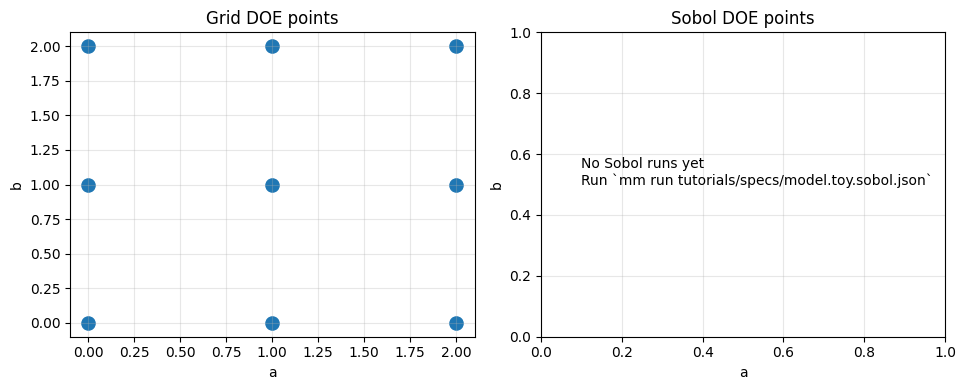

In [4]:
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

root = Path.cwd().resolve()
if not (root / "src").is_dir() and (root.parent / "src").is_dir():
    root = root.parent

grid_spec = json.loads((root / 'tutorials/specs/model.toy.grid.json').read_text())
sobol_spec = json.loads((root / 'tutorials/specs/model.toy.sobol.json').read_text())

# grid points
a_vals = grid_spec['design']['grid']['a']
b_vals = grid_spec['design']['grid']['b']
grid_pts = np.array([(a, b) for a in a_vals for b in b_vals], dtype=float)

# approximate sobol points from existing runs if available
runs_root = root / 'tmp/tutorials/toy_store_sobol/runs'
sobol_pts = []
if runs_root.exists():
    for run_dir in sorted(p for p in runs_root.iterdir() if p.is_dir()):
        inp = json.loads((run_dir / 'inputs.json').read_text())
        sobol_pts.append((inp['a'], inp['b']))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(grid_pts[:, 0], grid_pts[:, 1], s=90)
plt.title('Grid DOE points')
plt.xlabel('a')
plt.ylabel('b')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
if sobol_pts:
    sobol_arr = np.asarray(sobol_pts, dtype=float)
    plt.scatter(sobol_arr[:, 0], sobol_arr[:, 1], c='tab:orange', s=90)
    plt.title('Sobol DOE points (from runs)')
else:
    plt.text(0.1, 0.5, 'No Sobol runs yet\nRun `mm run tutorials/specs/model.toy.sobol.json`', fontsize=10)
    plt.title('Sobol DOE points')
plt.xlabel('a')
plt.ylabel('b')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## The actual lesson: curse of dimensionality

In 2D the scatter looks like a small win for Sobol, easy to miss. The win compounds with dimensionality:

| Dimensions | Grid (4 levels per dim) | Sobol for similar coverage |
|---:|---:|---:|
| 2 | 4² = **16** | ~16 |
| 3 | 4³ = **64** | ~32 |
| 4 | 4⁴ = **256** | ~64 |
| 5 | 4⁵ = **1024** | ~128 |
| 6 | 4⁶ = **4096** | ~256 |

The crossover where Sobol decisively wins is around 4D. By 6D you're paying 16x the compute for a comparable coverage with grid — and a lot of those grid runs cluster on faces and corners of the input box where the model behaves predictably anyway. Sobol places more runs in the interior where surrogates need them.


## Scientific checkpoint

Write a short decision note:

- When grid is better (think: very low-D, when uniform interpretability matters more than coverage, when downstream tools assume a regular lattice).
- When sobol is better (think: 4D+, when budget is fixed and coverage is the goal, when you'll use the points to train a surrogate that prefers space-filled inputs).
- Which one you'd pick for a 6-10D study and why.

**One more thing — Sobol is *deterministic*, not random.** Re-running `bayesmm plan tutorials/specs/model.toy.sobol.json` with the same `seed` produces *exactly the same* points every time. It's a low-discrepancy sequence, not a stochastic sample. That means: (1) reproducibility comes for free without any seed-pinning gymnastics, and (2) if you want different points, change the `seed` field in the spec — don't expect re-running to give variation.


## Troubleshooting

| Symptom | Cause | Fix |
|---|---|---|
| Sobol gives a different count than you asked for | Sobol sequences are most uniform at powers of two | Ask for 8, 16, 32… A request for 10 is honoured but the space-filling is measurably worse. |
| Grid explodes to thousands of points | Cartesian product — cost is exponential in dimension | 3 levels × 6 inputs is 729 runs. This is the whole reason Sobol exists; see the comparison above. |
| Two Sobol runs give different points | A seed changed | Sobol here is *deterministic*: same seed and count give identical points. If they differ, the spec's seed changed. |
| Sobol points look clumped in a 2-D plot | You're projecting >2 dimensions onto 2 | Space-filling is a property of the full space; any 2-D shadow of it can look clustered. |

**Carry this into T5:** DOE choice determines what your surrogate can learn. A grid
that never samples the interior leaves a GP interpolating across a gap it has no
evidence for — and it will report confident predictions there anyway.

## Final check: T4 ran both grid AND sobol sweeps

Asserts both `tmp/tutorials/toy_store/sweeps/...` (grid) and `tmp/tutorials/toy_store_sobol/sweeps/...` (sobol) have at least one sweep_rows.csv with ≥1 success row. If only one ran, the comparison scatter is misleading.

In [ ]:
# Self-check: BOTH grid and sobol sweeps ran (the comparison plot needs both).
from pathlib import Path as _P
import csv as _csv
def _count_success(roots):
    sweeps = sorted(roots.glob("*/sweep_rows.csv"), key=lambda p: p.stat().st_mtime)
    if not sweeps:
        return 0, None
    with open(sweeps[-1]) as f:
        rows = list(_csv.DictReader(f))
    return sum(1 for r in rows if r.get("status") == "success"), sweeps[-1]
_grid_n, _grid_p = _count_success(root / "tmp/tutorials/toy_store/sweeps")
_sobol_n, _sobol_p = _count_success(root / "tmp/tutorials/toy_store_sobol/sweeps")
assert _grid_n >= 9, f"Grid sweep has only {_grid_n} successful rows (expected ≥9). T1 sweep missing or failed."
assert _sobol_n >= 9, (
    f"Sobol sweep has only {_sobol_n} successful rows (expected ≥9). "
    "Step 2's bayesmm-run-on-sobol-spec didn't produce data."
)
print(f"\n[T4 self-check OK] grid: {_grid_n} success at {_grid_p.relative_to(root) if _grid_p else '?'}")
print(f"[T4 self-check OK] sobol: {_sobol_n} success at {_sobol_p.relative_to(root) if _sobol_p else '?'}")
